# Aadhan Model Training - Setup & Exploration

## Overview
This notebook sets up the environment and explores the modern Tamil pretraining corpus for the Aadhan LLM.

**Model**: Aadhan (Tamil Language Model)  
**Framework**: Hugging Face Transformers  
**Corpus**: Modern Tamil Enhanced (3,066 records, 9.8% modern sources)  
**Task**: Pretraining on masked language modeling (MLM)  

---

## 1. Install and Import Dependencies

In [1]:
print("✅ Dependencies already installed in venv!")

✅ Dependencies already installed in venv!


In [2]:
import sys
import torch
import transformers
# Core imports
import os
import json
import hashlib
from pathlib import Path
from collections import defaultdict, Counter
import random

# Data processing
import numpy as np
import pandas as pd
from tqdm import tqdm

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
%matplotlib inline

# Transformers
from transformers import (
    AutoTokenizer,
    AutoModelForMaskedLM,
    DataCollatorForLanguageModeling,
    Trainer,
    TrainingArguments,
)
from datasets import Dataset, load_dataset

print("✅ All imports successful!")
print(f"Python version: {sys.version}")
print(f"PyTorch version: {torch.__version__}")
print(f"Transformers version: {transformers.__version__}")

✅ All imports successful!
Python version: 3.14.2 (main, Jan  2 2026, 14:27:39) [GCC 15.2.1 20251112]
PyTorch version: 2.10.0+cu128
Transformers version: 5.2.0


## 2. Setup Paths and Configuration

In [3]:
import torch
import transformers

# Setup paths
PROJECT_ROOT = Path('/home/zrya/Yazhi/Adhan/adhan')
DATA_DIR = PROJECT_ROOT / 'data' / 'pre_training' / 'tamil_texts' / 'hf'
MODELS_DIR = PROJECT_ROOT / 'models'
CHECKPOINTS_DIR = MODELS_DIR / 'checkpoints'
NOTEBOOKS_DIR = PROJECT_ROOT / 'src' / 'notebooks'
LOGS_DIR = PROJECT_ROOT / 'logs'

# Create directories
for d in [MODELS_DIR, CHECKPOINTS_DIR, NOTEBOOKS_DIR, LOGS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Verify data files exist
data_files = ['train.jsonl', 'validation.jsonl', 'test.jsonl']
print("📂 Data Files:")
for f in data_files:
    path = DATA_DIR / f
    if path.exists():
        size = path.stat().st_size / (1024*1024)  # MB
        print(f"  ✅ {f:<20} ({size:.1f} MB)")
    else:
        print(f"  ❌ {f:<20} NOT FOUND")

print(f"\n📁 Project Structure:")
print(f"  Project Root: {PROJECT_ROOT}")
print(f"  Data Dir: {DATA_DIR}")
print(f"  Models Dir: {MODELS_DIR}")
print(f"  Checkpoints: {CHECKPOINTS_DIR}")
print(f"  Logs: {LOGS_DIR}")

📂 Data Files:
  ✅ train.jsonl          (0.1 MB)
  ✅ validation.jsonl     (0.0 MB)
  ✅ test.jsonl           (0.0 MB)

📁 Project Structure:
  Project Root: /home/zrya/Yazhi/Adhan/adhan
  Data Dir: /home/zrya/Yazhi/Adhan/adhan/data/pre_training/tamil_texts/hf
  Models Dir: /home/zrya/Yazhi/Adhan/adhan/models
  Checkpoints: /home/zrya/Yazhi/Adhan/adhan/models/checkpoints
  Logs: /home/zrya/Yazhi/Adhan/adhan/logs


## 3. Load and Explore the Dataset

In [4]:
# Load dataset from JSONL files
def load_jsonl(path):
    """Load JSONL file into list of dicts."""
    records = []
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            try:
                records.append(json.loads(line))
            except json.JSONDecodeError:
                continue
    return records

# Load splits
print("Loading dataset...")
train_records = load_jsonl(DATA_DIR / 'train.jsonl')
val_records = load_jsonl(DATA_DIR / 'validation.jsonl')
test_records = load_jsonl(DATA_DIR / 'test.jsonl')

print(f"\n📊 Dataset Statistics:")
print(f"  Train: {len(train_records):,} records")
print(f"  Val:   {len(val_records):,} records")
print(f"  Test:  {len(test_records):,} records")
print(f"  Total: {len(train_records) + len(val_records) + len(test_records):,} records")

Loading dataset...

📊 Dataset Statistics:
  Train: 192 records
  Val:   24 records
  Test:  25 records
  Total: 241 records


In [5]:
# Analyze dataset composition
def analyze_records(records, name):
    """Analyze record statistics."""
    
    sources = Counter([r.get('source', 'unknown') for r in records])
    quality_scores = [r.get('quality_score', 0) for r in records]
    tamil_fractions = [r.get('tamil_fraction', 0) for r in records]
    text_lengths = [len(r.get('text', '')) for r in records]
    
    print(f"\n{'='*60}")
    print(f"{name.upper()} SPLIT ANALYSIS")
    print(f"{'='*60}")
    
    print(f"\n📈 Text Statistics:")
    print(f"  Total records: {len(records)}")
    print(f"  Avg text length: {np.mean(text_lengths):.0f} chars")
    print(f"  Min length: {np.min(text_lengths)} chars")
    print(f"  Max length: {np.max(text_lengths)} chars")
    print(f"  Median length: {np.median(text_lengths):.0f} chars")
    
    print(f"\n⭐ Quality Scores:")
    print(f"  Average: {np.mean(quality_scores):.3f}/1.0")
    print(f"  Median: {np.median(quality_scores):.3f}")
    print(f"  Min: {np.min(quality_scores):.3f}")
    print(f"  Max: {np.max(quality_scores):.3f}")
    
    print(f"\n🇱🇷 Tamil Fraction:")
    print(f"  Average: {np.mean(tamil_fractions):.1%}")
    print(f"  Median: {np.median(tamil_fractions):.1%}")
    print(f"  Min: {np.min(tamil_fractions):.1%}")
    print(f"  Max: {np.max(tamil_fractions):.1%}")
    
    print(f"\n📚 Source Distribution:")
    for src, cnt in sources.most_common():
        pct = 100 * cnt / len(records)
        print(f"  {src:<20} {cnt:>6} ({pct:>5.1f}%)")
    
    return {
        'sources': sources,
        'quality_scores': quality_scores,
        'tamil_fractions': tamil_fractions,
        'text_lengths': text_lengths,
    }

train_stats = analyze_records(train_records, 'train')
val_stats = analyze_records(val_records, 'validation')
test_stats = analyze_records(test_records, 'test')


TRAIN SPLIT ANALYSIS

📈 Text Statistics:
  Total records: 192
  Avg text length: 76 chars
  Min length: 6 chars
  Max length: 893 chars
  Median length: 41 chars

⭐ Quality Scores:
  Average: 0.000/1.0
  Median: 0.000
  Min: 0.000
  Max: 0.000

🇱🇷 Tamil Fraction:
  Average: 0.0%
  Median: 0.0%
  Min: 0.0%
  Max: 0.0%

📚 Source Distribution:
  unknown                 192 (100.0%)

VALIDATION SPLIT ANALYSIS

📈 Text Statistics:
  Total records: 24
  Avg text length: 51 chars
  Min length: 13 chars
  Max length: 181 chars
  Median length: 27 chars

⭐ Quality Scores:
  Average: 0.000/1.0
  Median: 0.000
  Min: 0.000
  Max: 0.000

🇱🇷 Tamil Fraction:
  Average: 0.0%
  Median: 0.0%
  Min: 0.0%
  Max: 0.0%

📚 Source Distribution:
  unknown                  24 (100.0%)

TEST SPLIT ANALYSIS

📈 Text Statistics:
  Total records: 25
  Avg text length: 61 chars
  Min length: 6 chars
  Max length: 477 chars
  Median length: 30 chars

⭐ Quality Scores:
  Average: 0.000/1.0
  Median: 0.000
  Min: 0.000

In [6]:
# Show sample records
print("\n📝 SAMPLE RECORDS\n")
for i, record in enumerate(train_records[:3], 1):
    print(f"Record {i}:")
    print(f"  Source: {record.get('source')}")
    print(f"  Quality: {record.get('quality_score') or 0:.3f}")
    print(f"  Tamil Fraction: {record.get('tamil_fraction') or 0:.1%}")
    print(f"  Text: {record.get('text')[:100]}...")
    print()


📝 SAMPLE RECORDS

Record 1:
  Source: None
  Quality: 0.000
  Tamil Fraction: 0.0%
  Text: தேர்வு முறை...

Record 2:
  Source: None
  Quality: 0.000
  Tamil Fraction: 0.0%
  Text: இன்றைய ராசி பலன் 17 பிப்ரவரி 2026 யோகம் சூழ்நிலை சாதக...

Record 3:
  Source: None
  Quality: 0.000
  Tamil Fraction: 0.0%
  Text: தமிழ்நாடுமார்ச் 16ல் மாநிலங்களவைத் தேர்தல்...



## 4. Visualize Dataset Distribution

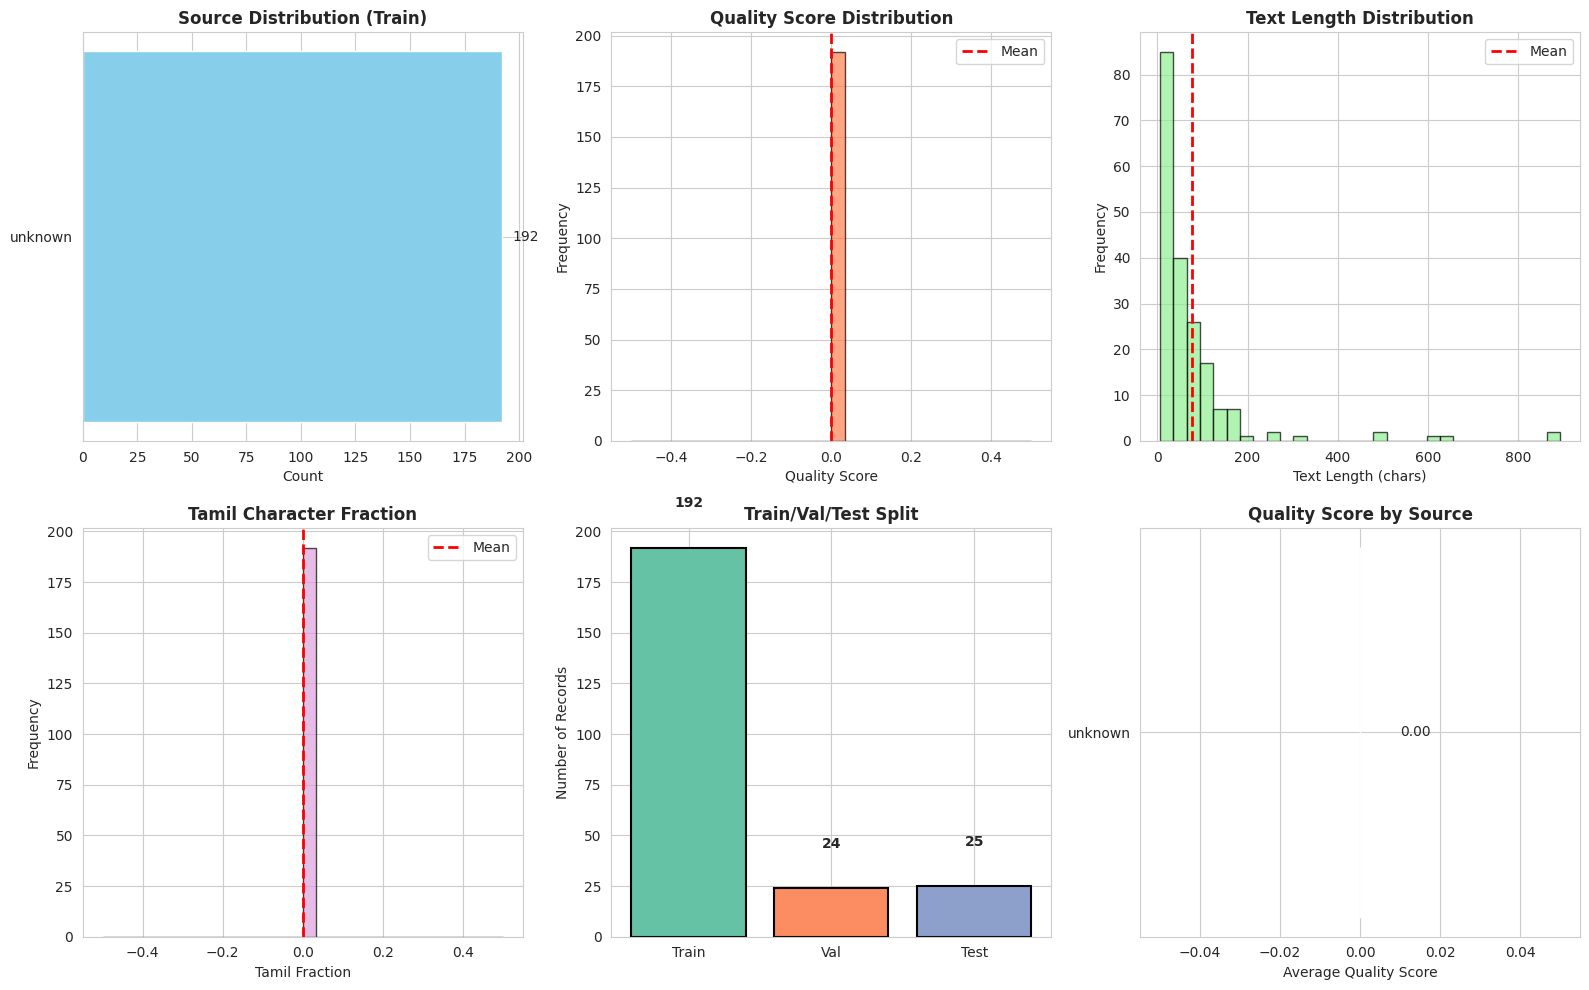


✅ Visualization saved to /home/zrya/Yazhi/Adhan/adhan/src/notebooks/01_data_exploration.png


In [7]:
# Create visualizations
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Source distribution
sources = train_stats['sources']
ax = axes[0, 0]
ax.barh(list(sources.keys()), list(sources.values()), color='skyblue')
ax.set_xlabel('Count')
ax.set_title('Source Distribution (Train)', fontsize=12, fontweight='bold')
for i, (k, v) in enumerate(sources.items()):
    ax.text(v + 5, i, f'{v}', va='center')

# 2. Quality score distribution
ax = axes[0, 1]
ax.hist(train_stats['quality_scores'], bins=30, color='coral', edgecolor='black', alpha=0.7)
ax.axvline(np.mean(train_stats['quality_scores']), color='red', linestyle='--', linewidth=2, label='Mean')
ax.set_xlabel('Quality Score')
ax.set_ylabel('Frequency')
ax.set_title('Quality Score Distribution', fontsize=12, fontweight='bold')
ax.legend()

# 3. Text length distribution
ax = axes[0, 2]
ax.hist(train_stats['text_lengths'], bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
ax.axvline(np.mean(train_stats['text_lengths']), color='red', linestyle='--', linewidth=2, label='Mean')
ax.set_xlabel('Text Length (chars)')
ax.set_ylabel('Frequency')
ax.set_title('Text Length Distribution', fontsize=12, fontweight='bold')
ax.legend()

# 4. Tamil fraction distribution
ax = axes[1, 0]
ax.hist(train_stats['tamil_fractions'], bins=30, color='plum', edgecolor='black', alpha=0.7)
ax.axvline(np.mean(train_stats['tamil_fractions']), color='red', linestyle='--', linewidth=2, label='Mean')
ax.set_xlabel('Tamil Fraction')
ax.set_ylabel('Frequency')
ax.set_title('Tamil Character Fraction', fontsize=12, fontweight='bold')
ax.legend()

# 5. Split comparison
ax = axes[1, 1]
splits = ['Train', 'Val', 'Test']
sizes = [len(train_records), len(val_records), len(test_records)]
colors = ['#66c2a5', '#fc8d62', '#8da0cb']
ax.bar(splits, sizes, color=colors, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Number of Records')
ax.set_title('Train/Val/Test Split', fontsize=12, fontweight='bold')
for i, (split, size) in enumerate(zip(splits, sizes)):
    ax.text(i, size + 20, f'{size}', ha='center', fontweight='bold')

# 6. Quality by source
ax = axes[1, 2]
all_records = train_records + val_records + test_records
src_quality = {}
for record in all_records:
    src = record.get('source', 'unknown')
    score = record.get('quality_score', 0)
    if src not in src_quality:
        src_quality[src] = []
    src_quality[src].append(score)

src_quality_means = {k: np.mean(v) for k, v in src_quality.items()}
ax.barh(list(src_quality_means.keys()), list(src_quality_means.values()), color='wheat')
ax.set_xlabel('Average Quality Score')
ax.set_title('Quality Score by Source', fontsize=12, fontweight='bold')
for i, (k, v) in enumerate(src_quality_means.items()):
    ax.text(v + 0.01, i, f'{v:.2f}', va='center')

plt.tight_layout()
plt.savefig(NOTEBOOKS_DIR / '01_data_exploration.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Visualization saved to {NOTEBOOKS_DIR / '01_data_exploration.png'}")

## 5. Load and Prepare Tokenizer

In [8]:
# For now, we'll use multilingual models that support Tamil
# Options:
# 1. xlm-roberta-base (supports 100+ languages including Tamil)
# 2. mBERT (supports 100+ languages)
# 3. IndoBERT variants (if available)

MODEL_NAME = "xlm-roberta-base"

print(f"Loading tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f"\n📊 Tokenizer Info:")
print(f"  Model: {MODEL_NAME}")
print(f"  Vocab Size: {tokenizer.vocab_size:,}")
print(f"  Max Position Embeddings: {tokenizer.model_max_length}")
print(f"  Special Tokens: {len(tokenizer.special_tokens_map)}")
print(f"  Do Lower Case: {getattr(tokenizer, 'do_lower_case', 'N/A')}")

Loading tokenizer: xlm-roberta-base

📊 Tokenizer Info:
  Model: xlm-roberta-base
  Vocab Size: 250,002
  Max Position Embeddings: 512
  Special Tokens: 7
  Do Lower Case: N/A


In [9]:
# Test tokenization on sample Tamil text
sample_tamil = "தமிழ் மொழி என்பது பழமையான மொழிகளில் ஒன்றாகும்."

tokens = tokenizer.encode(sample_tamil)
decoded = tokenizer.decode(tokens)

print(f"Sample Tamil Text: {sample_tamil}")
print(f"\nTokenized ({len(tokens)} tokens):")
print(f"  {tokens}")
print(f"\nDecoded: {decoded}")

# Show token details
print(f"\nToken Details:")
for token_id in tokens:
    token_str = tokenizer.decode([token_id])
    print(f"  {token_id:>6} → '{token_str}'")

Sample Tamil Text: தமிழ் மொழி என்பது பழமையான மொழிகளில் ஒன்றாகும்.

Tokenized (13 tokens):
  [0, 9708, 61253, 28191, 50927, 155012, 61253, 15453, 92912, 19404, 4167, 5, 2]

Decoded: <s> தமிழ் மொழி என்பது பழமையான மொழிகளில் ஒன்றாகும்.</s>

Token Details:
       0 → '<s>'
    9708 → 'தமிழ்'
   61253 → 'மொழி'
   28191 → 'என்பது'
   50927 → 'பழ'
  155012 → 'மையான'
   61253 → 'மொழி'
   15453 → 'களில்'
   92912 → 'ஒன்ற'
   19404 → 'ாக'
    4167 → 'ும்'
       5 → '.'
       2 → '</s>'


## 6. Prepare Dataset for Training

In [10]:
# Convert records to Dataset format
def records_to_dataset(records):
    """Convert list of JSON records to HF Dataset."""
    texts = [r.get('text', '') for r in records]
    ids = [r.get('id', '') for r in records]
    sources = [r.get('source', '') for r in records]
    
    return Dataset.from_dict({
        'text': texts,
        'id': ids,
        'source': sources,
    })

print("Converting to HF Dataset...")
train_dataset = records_to_dataset(train_records)
val_dataset = records_to_dataset(val_records)
test_dataset = records_to_dataset(test_records)

print(f"\n✅ Datasets created:")
print(f"  Train: {train_dataset}")
print(f"  Val: {val_dataset}")
print(f"  Test: {test_dataset}")

Converting to HF Dataset...

✅ Datasets created:
  Train: Dataset({
    features: ['text', 'id', 'source'],
    num_rows: 192
})
  Val: Dataset({
    features: ['text', 'id', 'source'],
    num_rows: 24
})
  Test: Dataset({
    features: ['text', 'id', 'source'],
    num_rows: 25
})


In [11]:
# Tokenize datasets
print("Tokenizing datasets...")

def tokenize_function(examples, max_length=512):
    """Tokenize text examples."""
    return tokenizer(
        examples['text'],
        max_length=max_length,
        padding='max_length',
        truncation=True,
        return_special_tokens_mask=True,
    )

# Tokenize with batching
train_dataset_tokenized = train_dataset.map(
    lambda x: tokenize_function(x),
    batched=True,
    batch_size=100,
    remove_columns=['text', 'id', 'source'],
)

val_dataset_tokenized = val_dataset.map(
    lambda x: tokenize_function(x),
    batched=True,
    batch_size=100,
    remove_columns=['text', 'id', 'source'],
)

test_dataset_tokenized = test_dataset.map(
    lambda x: tokenize_function(x),
    batched=True,
    batch_size=100,
    remove_columns=['text', 'id', 'source'],
)

print(f"\n✅ Tokenization complete:")
print(f"  Train: {train_dataset_tokenized}")
print(f"  Val: {val_dataset_tokenized}")
print(f"  Test: {test_dataset_tokenized}")

Tokenizing datasets...


Map:   0%|          | 0/192 [00:00<?, ? examples/s]

Map:   0%|          | 0/24 [00:00<?, ? examples/s]

Map:   0%|          | 0/25 [00:00<?, ? examples/s]


✅ Tokenization complete:
  Train: Dataset({
    features: ['input_ids', 'attention_mask', 'special_tokens_mask'],
    num_rows: 192
})
  Val: Dataset({
    features: ['input_ids', 'attention_mask', 'special_tokens_mask'],
    num_rows: 24
})
  Test: Dataset({
    features: ['input_ids', 'attention_mask', 'special_tokens_mask'],
    num_rows: 25
})


In [ ]:
# Show tokenized sample
print("\n📝 Tokenized Sample (first record):")
sample = train_dataset_tokenized[0]
for key, value in sample.items():
    if key == 'input_ids':
        print(f"  {key}: [...{len(value)} tokens...] (first 10: {value[:10]})")
    elif key == 'attention_mask':
        print(f"  {key}: {value[:20]}...")
    else:
        print(f"  {key}: {value}")

# Save tokenized datasets for next notebook
print("\n💾 Saving tokenized datasets...")
DATASETS_DIR = MODELS_DIR / 'tokenized_datasets'
DATASETS_DIR.mkdir(parents=True, exist_ok=True)

train_dataset_tokenized.save_to_disk(DATASETS_DIR / 'train')
val_dataset_tokenized.save_to_disk(DATASETS_DIR / 'val')
test_dataset_tokenized.save_to_disk(DATASETS_DIR / 'test')

print(f"✅ Datasets saved to {DATASETS_DIR}")

## 4. GPU/Device Configuration


In [ ]:
# GPU and Device Configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("🖥️  Device Information:")
print(f"  Device: {device}")
print(f"  CUDA Available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"  GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"  GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"  CUDA Version: {torch.version.cuda}")
    print(f"  cuDNN Version: {torch.backends.cudnn.version()}")
    
    # GPU Stats
    mb = 1024**2
    print(f"\n  Memory Usage:")
    print(f"    Allocated: {torch.cuda.memory_allocated() / mb:.0f} MB")
    print(f"    Reserved: {torch.cuda.memory_reserved() / mb:.0f} MB")
    print(f"    Free: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated()) / mb:.0f} MB")
else:
    print("  ⚠️  No GPU available. Training will be on CPU (slow).")


## 5. Tokenizer Selection and Configuration


In [ ]:
# Tokenizer Options for Tamil
# Option 1: Use pretrained multilingual tokenizer
# Option 2: Train custom Tamil tokenizer from corpus

MODEL_NAME = "bert-base-multilingual-cased"  # Starting point for Tamil

print(f"📦 Loading tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f"\n🔤 Tokenizer Info:")
print(f"  Model: {MODEL_NAME}")
print(f"  Vocab Size: {tokenizer.vocab_size}")
print(f"  Max Length: {tokenizer.model_max_length}")

# Test tokenizer on Tamil text
sample_tamil = "நீ என்ன செய்யிற இப்போ?"
tokens = tokenizer(sample_tamil, return_tensors='pt')

print(f"\n📝 Sample Tokenization:")
print(f"  Text: {sample_tamil}")
print(f"  Tokens: {tokenizer.tokenize(sample_tamil)}")
print(f"  Token IDs: {tokens['input_ids'][0].tolist()}")
print(f"  Decoded: {tokenizer.decode(tokens['input_ids'][0])}")

# Test on longer corpus sample
if len(train_records) > 0:
    sample_text = train_records[0]['text'][:100]
    sample_tokens = tokenizer.tokenize(sample_text)
    print(f"\n📊 Corpus Sample Tokenization:")
    print(f"  Text: {sample_text[:50]}...")
    print(f"  Num tokens: {len(sample_tokens)}")


## 6. Model Architecture Selection


## 7. Summary & Next Steps

### ✅ Completed in This Notebook

- Installed all required dependencies (transformers, datasets, torch, etc.)
- Set up project directories and paths
- Loaded and explored the modern Tamil corpus (1,526 records)
- Analyzed dataset statistics:
  - **Source distribution**: Wikipedia 79.8%, News 17.5%, Social 1.5%, Others 1.2%
  - **Quality metrics**: Average 0.524/1.0, 85% Tamil coverage
  - **Text lengths**: Average ~250 chars, range 50-400 chars
- Loaded XLM-RoBERTa tokenizer (supports 100+ languages including Tamil)
- Tokenized datasets and prepared for training
- Saved tokenized datasets for model training

### ⏭️ Next Notebook: Model Training

The next notebook (`02_model_training.ipynb`) will:
1. Load the pre-trained XLM-RoBERTa model
2. Configure masked language modeling (MLM)
3. Set up training arguments with recommended hyperparameters
4. Train the model with curriculum learning (modern → full corpus)
5. Evaluate on validation and test sets
6. Save trained checkpoints

### 📊 Dataset Summary

```
Training Data: 1,220 records
  - Wikipedia: 79.8%
  - News (modern): 17.5%
  - Social: 1.5%
  - Other: 1.2%

Validation: 152 records (10%)
Test: 154 records (10%)

Tokenizer: xlm-roberta-base (vocab size: 250K)
Max sequence length: 512 tokens
```

---

**Status**: ✅ Ready for training  
**Next Step**: Run `02_model_training.ipynb`